# Get the inflexion point for RIDGE and LASSO

In [1]:
import pandas as pd
import os

In [2]:
csv_path = "Results/feature_selection/RNAseq/ridge_L2_0/"
file_list = os.listdir(csv_path)
file_list = [f for f in file_list if f.endswith('_Symbols.csv')]
file_list

['Experiment_GSE129643_feature_selection_Symbols.csv',
 'Experiment_GSE167186_feature_selection_Symbols.csv',
 'Experiment_GSE152558_feature_selection_Symbols.csv',
 'Sex_male_feature_selection_Symbols.csv',
 'Status_Sarcopenia_feature_selection_Symbols.csv',
 'Status_Healthy_feature_selection_Symbols.csv',
 'Experiment_GSE60590_feature_selection_Symbols.csv',
 'Experiment_GSE157585_feature_selection_Symbols.csv',
 'Experiment_GSE164471_feature_selection_Symbols.csv',
 'Sex_female_feature_selection_Symbols.csv',
 'Status_trained_feature_selection_Symbols.csv']

In [3]:
csv_file = csv_path + file_list[0]
csv_file

'Results/feature_selection/RNAseq/ridge_L2_0/Experiment_GSE129643_feature_selection_Symbols.csv'

Index(['Unnamed: 0', 'coef', 'abs_coef'], dtype='object')

In [10]:
gene_rank_df = pd.read_csv(csv_file)
    # check the first rows of the dataframe, if it starts with "","coef","abs_coef","NULL", replace NULL with "Symbol" and "" with "Ensembl"
gene_rank_df.columns = ["Ensembl","coef","abs_coef","Symbol"]
if gene_rank_df.columns[0] == "V1":
    gene_rank_df.columns = ["Ensembl","coef","abs_coef","Symbol"]
    # remove first row
    gene_rank_df = gene_rank_df.iloc[1:]
# check if the first row value is NaN
if gene_rank_df.iloc[0][1] == "coef":
    gene_rank_df = gene_rank_df.iloc[1:]

gene_rank_df = gene_rank_df.fillna(0)
gene_rank_df["abs_coef"] = pd.to_numeric(gene_rank_df["abs_coef"], errors='coerce')
gene_rank_df

/tmp/ipykernel_85695/2202445406.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


,Ensembl,coef,abs_coef,Symbol
1,ENSG00000211841.1,0.34199139319400984,3.419914e-01,TRAJ48
2,ENSG00000211844.1,0.32009927753792056,3.200993e-01,TRAJ45
3,ENSG00000225840.2,0.3153558606088578,3.153559e-01,0
4,ENSG00000201610.1,0.28884367064371297,2.888437e-01,RNA5SP84
5,ENSG00000152926.14,0.2458695472620035,2.458695e-01,ZNF117
...,...,...,...,...
34501,ENSG00000256274.1,-4.98287119145941e-07,4.982871e-07,TAS2R64P
34502,ENSG00000234522.1,-4.964102813321383e-07,4.964103e-07,0
34503,ENSG00000235169.8,-4.585671544571097e-07,4.585672e-07,SMIM1
34504,ENSG00000162006.9,4.3498665215176865e-07,4.349867e-07,MSLNL


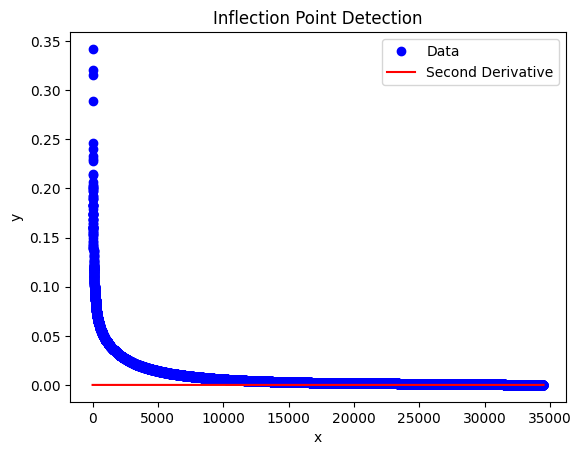

Inflection point at x = Index([], dtype='int64')


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define a function for the curve fit
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Generate sample data (replace with your actual data)
x_data = gene_rank_df.index
y_data = gene_rank_df["abs_coef"]

# Fit the data to the curve
popt, pcov = curve_fit(func, x_data, y_data)

# Calculate the second derivative of the fitted curve
def second_derivative(x):
    return popt[0] * popt[1]**2 * np.exp(-popt[1] * x)

# Find the inflection point (where the second derivative changes sign)
x_inflection = gene_rank_df.index
y_inflection = second_derivative(x_inflection)

sign_change_indices = np.where(np.diff(np.sign(y_inflection)))[0]
inflection_point = x_inflection[sign_change_indices]

# Plot the data and the fitted curve
plt.plot(x_data, y_data, 'bo', label='Data')
plt.plot(x_inflection, y_inflection, 'r-', label='Second Derivative')
#plt.axvline(inflection_point, color='g', linestyle='--', label='Inflection Point')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Inflection Point Detection')
plt.show()

print("Inflection point at x =", inflection_point)


In [18]:
# average 
y_inflection
average_y_inflection = y_inflection.values.mean()
average_y_inflection


1.645933102605603e-09

In [12]:
inflection_point

array([], dtype=float64)

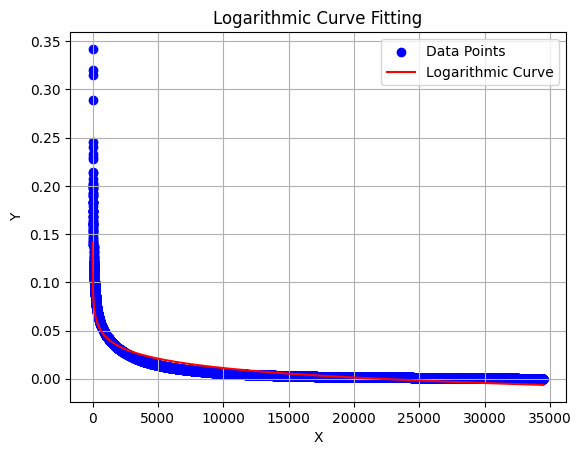

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
x = gene_rank_df.index
y = gene_rank_df["abs_coef"]

# Fit a logarithmic curve
coefficients = np.polyfit(np.log(x), y, 1)  # Fit a first-degree polynomial (straight line) to the logarithm of x

# Generate curve points
x_curve = np.linspace(min(x), max(x), 1000)
y_curve = np.polyval(coefficients, np.log(x_curve))

# Plot the data points
plt.scatter(x, y, label='Data Points', color='blue')

# Plot the logarithmic curve
plt.plot(x_curve, y_curve, label='Logarithmic Curve', color='red')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Logarithmic Curve Fitting')
plt.legend()
plt.grid(True)
plt.show()


In [112]:
y_curve[450:490]


array([0.0048931 , 0.00486175, 0.00483048, 0.00479927, 0.00476812,
       0.00473705, 0.00470605, 0.00467511, 0.00464424, 0.00461344,
       0.00458271, 0.00455204, 0.00452144, 0.0044909 , 0.00446043,
       0.00443003, 0.00439969, 0.00436942, 0.00433921, 0.00430907,
       0.00427899, 0.00424897, 0.00421902, 0.00418913, 0.0041593 ,
       0.00412954, 0.00409984, 0.0040702 , 0.00404063, 0.00401111,
       0.00398166, 0.00395227, 0.00392294, 0.00389367, 0.00386446,
       0.00383531, 0.00380622, 0.00377719, 0.00374822, 0.00371931])

In [119]:
dy_dx = np.gradient(np.gradient(y_curve))


In [150]:


# Calculate the second derivative using central differences
d2y_dx2 = np.gradient(np.gradient(dy_dx))


In [148]:
## get the index of the point where dy_dx on i-1 is more than dy_dx on i  + dy_dx on i+1
inflection_point = []
for i in range(1,len(d2y_dx2)-10):
    if d2y_dx2[i-2] > d2y_dx2[i+1] + d2y_dx2[i+2]:
        inflection_point.append(i)
inflection_point

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [166]:
## get the index of the point where dy_dx on i-1 is more than dy_dx on i  + dy_dx on i+1
inflection_point_2 = []
for i in range(1,len(d2y_dx2)-10):
    if d2y_dx2[i-2] < d2y_dx2[i] :
        inflection_point_2.append(i)
inflection_point_2

[2, 3, 4]

In [151]:
max_change = inflection_point[-1]
alpha=y_curve[max_change]
y_curve[max_change]

0.048846869647841115

In [160]:
y_curve[5]

0.06836488411764886

In [152]:
max_change

20

In [156]:
d2y_dx2[2]

-0.0009365720398615864

In [154]:
d2y_dx2[2:24]

array([-9.36572040e-04,  4.49155285e-03,  2.74907232e-03,  2.76085140e-04,
        1.00458022e-04,  4.73356720e-05,  2.56431237e-05,  1.52199822e-05,
        9.64680085e-06,  6.42794364e-06,  4.45605611e-06,  3.19024539e-06,
        2.34607001e-06,  1.76487276e-06,  1.35377448e-06,  1.05615580e-06,
        8.36289604e-07,  6.70949984e-07,  5.44639799e-07,  4.46778721e-07,
        3.69994347e-07,  3.09054823e-07])

In [161]:
# Find the inflection point (where the second derivative changes sign)
sign_change_indices = np.where(np.diff(np.sign(d2y_dx2)))[0]
sign_change_indices

array([  2, 995, 998])

In [27]:
delta_values = np.diff(y_curve)

In [117]:
delta_values_series = pd.Series(d2y_dx2[300:-500])
delta_values_series= delta_values_series.abs()
delta_values_series.describe()

count    2.000000e+02
mean     4.122928e-12
std      2.467471e-12
min      1.366502e-12
25%      2.079975e-12
50%      3.326134e-12
75%      5.661983e-12
max      1.045926e-11
dtype: float64

In [118]:
min_abs_index = delta_values_series.abs().idxmax()
min_abs_index

0

In [71]:
delta_values_series = pd.Series(delta_values)
delta_values_series= delta_values_series.abs()
delta_values_series.describe()

count    999.000000
mean       0.000148
std        0.001648
min        0.000014
25%        0.000019
50%        0.000028
75%        0.000056
max        0.050429
dtype: float64

In [79]:
delta_values_2 = np.diff(delta_values)
delta_values_2_series = pd.Series(delta_values_2)

delta_values_2_series.describe()

count    9.980000e+02
mean     5.051600e-05
std      1.300012e-03
min      1.417921e-08
25%      2.519019e-08
50%      5.660031e-08
75%      2.254741e-07
max      4.083966e-02
dtype: float64

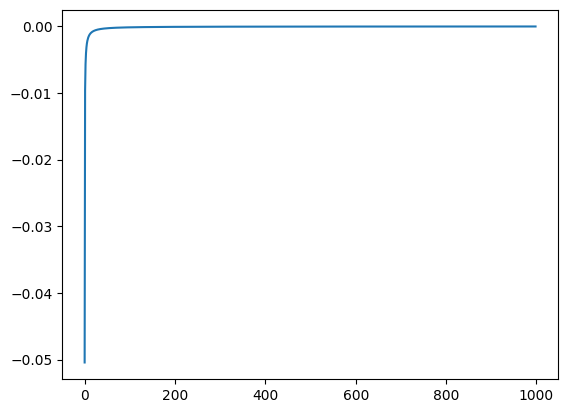

In [77]:
# Plot delta values
plt.plot(delta_values)

In [65]:
y_curve_series = pd.Series(y_curve)


In [73]:
index_change = np.where((delta_values_series[:-2] < delta_values_series[:-1]) & (delta_values_series[:-1] > delta_values_series[2:]))
index_change
#inflexion_index = index_change[0]
#inflexion_index

ValueError: Can only compare identically-labeled Series objects

In [58]:
y_curve[475:485]

array([0.00412954, 0.00409984, 0.0040702 , 0.00404063, 0.00401111,
       0.00398166, 0.00395227, 0.00392294, 0.00389367, 0.00386446])

In [46]:
min_abs_index = delta_values_series.abs().idxmax()
min_abs_index

0

In [43]:
alpha = y_curve[inflexion_index]
alpha

7.378805421176526e-06

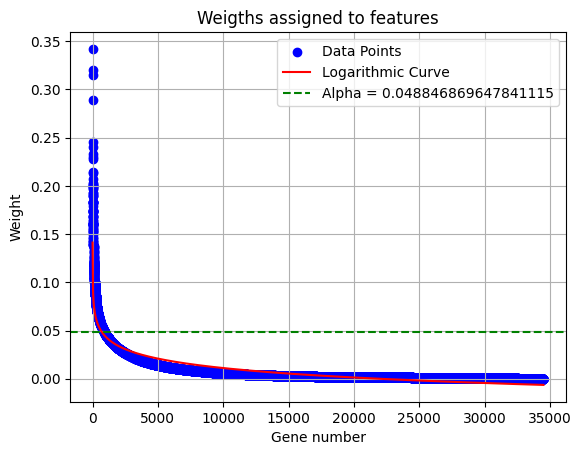

In [168]:
plt.scatter(x, y, label='Data Points', color='blue')

# Plot the logarithmic curve
plt.plot(x_curve, y_curve, label='Logarithmic Curve', color='red')
plt.axhline(y=alpha, color='green', linestyle='--', label=f'Alpha = {alpha}')

plt.xlabel('Gene number')
plt.ylabel('Weight')
plt.title('Weigths assigned to features')
plt.legend()
plt.grid(True)
plt.show()

In [169]:
gene_rank_df = gene_rank_df[gene_rank_df["abs_coef"]>alpha]

In [170]:
gene_rank_df

,Ensembl,coef,abs_coef,Symbol
1,ENSG00000211841.1,0.34199139319400984,0.341991,TRAJ48
2,ENSG00000211844.1,0.32009927753792056,0.320099,TRAJ45
3,ENSG00000225840.2,0.3153558606088578,0.315356,0
4,ENSG00000201610.1,0.28884367064371297,0.288844,RNA5SP84
5,ENSG00000152926.14,0.2458695472620035,0.245870,ZNF117
...,...,...,...,...
880,ENSG00000111058.7,-0.04908747360713735,0.049087,ACSS3
881,ENSG00000143226.13,0.049087208517813556,0.049087,FCGR2A
882,ENSG00000264343.5,-0.04907351865806485,0.049074,NOTCH2NLA
883,ENSG00000176171.11,-0.049045266411872894,0.049045,BNIP3


In [4]:
import getting_threshold_genes as gtg

rank_genes = gtg.get_gene_rank(csv_file)
alpha = gtg.get_inflexion_point_from_gene_rank(rank_genes)
alpha

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


0.048846869647841115